# Import Libraries

In [1]:
import numpy as np
import pandas as pd 

### Data loading

In [2]:
# For SKUs starting with '90'
# Data loading
df = pd.read_csv('../data/ForecastDataset_from_2016_to_2025_for_SKUs_started_with_90.csv')

In [3]:
df.shape

(533948, 9)

In [4]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_Category,Channel,ShipToState
0,AIRD,62181848,12/19/2022,Air Doctor AD3000,1,90AD01AD01,Cross Sell,SEM_Radial,VA
1,AIRD,60849149,7/8/2021,Air Doctor AD1000 Tower,1,90AD01AT01-W,Unit,DIG_OTHER_Radial,PA
2,AIRD,60849335,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,OR
3,AIRD,60849349,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,MT
4,AIRD,60849449,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,DIG_INFLCR_Radial,MD


In [5]:
df.columns

Index(['ProductFamily', 'Order_ID', 'OrderDate', 'SKU_Description',
       'WareHouseQuantity', 'SKU', 'SKU_Category', 'Channel', 'ShipToState'],
      dtype='object')

In [6]:
df.nunique()

ProductFamily             1
Order_ID             479881
OrderDate              3103
SKU_Description          20
WareHouseQuantity        13
SKU                      21
SKU_Category              3
Channel                  34
ShipToState              88
dtype: int64

In [7]:
df.isna().sum()

ProductFamily          0
Order_ID               0
OrderDate              0
SKU_Description      544
WareHouseQuantity      0
SKU                    0
SKU_Category         544
Channel               12
ShipToState           92
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.shape

(533300, 9)

### Feature Engineering

In [10]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
df['Month'] = df['OrderDate'].dt.month
df['Year'] = df['OrderDate'].dt.year

In [11]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_Category,Channel,ShipToState,Week,Month,Year
0,AIRD,62181848,2022-12-19,Air Doctor AD3000,1,90AD01AD01,Cross Sell,SEM_Radial,VA,2022-12-19,12,2022
1,AIRD,60849149,2021-07-08,Air Doctor AD1000 Tower,1,90AD01AT01-W,Unit,DIG_OTHER_Radial,PA,2021-07-05,7,2021
2,AIRD,60849335,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,OR,2021-07-05,7,2021
3,AIRD,60849349,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,MT,2021-07-05,7,2021
4,AIRD,60849449,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,DIG_INFLCR_Radial,MD,2021-07-05,7,2021


### Range Of SKU's

In [12]:
def print_date_ranges(df, sku_list=None):
    """
    Prints the overall dataset date range and individual date ranges for specified SKUs.

    Parameters:
    df (pd.DataFrame): DataFrame containing at least 'OrderDate' and 'SKU' columns.
    sku_list (list, optional): List of SKU strings to check date ranges for.
    """
    print("Full dataset date range:", df['OrderDate'].min(), "to", df['OrderDate'].max())
    
    if sku_list:
        for sku in sku_list:
            df_sku_check = df[df['SKU'] == sku]
            if not df_sku_check.empty:
                print(f"Selected SKU date range {sku}:", df_sku_check['OrderDate'].min(), "to", df_sku_check['OrderDate'].max())
                # print(f"Total weekly data points for this SKU: {df_sku_check.shape[0]}")
            else:
                print(f"No data found for SKU: {sku}")
                


In [13]:
sku_list = ['90AD350AD01', '90AD200AD01', '90AD01AT01-W', '90AD02AD01', '90AD550AD01']
print_date_ranges(df, sku_list)


Full dataset date range: 2016-12-23 00:00:00 to 2025-07-29 00:00:00
Selected SKU date range 90AD350AD01: 2022-09-15 00:00:00 to 2025-07-29 00:00:00
Selected SKU date range 90AD200AD01: 2022-06-04 00:00:00 to 2025-07-28 00:00:00
Selected SKU date range 90AD01AT01-W: 2019-08-16 00:00:00 to 2025-07-28 00:00:00
Selected SKU date range 90AD02AD01: 2021-05-25 00:00:00 to 2023-06-30 00:00:00
Selected SKU date range 90AD550AD01: 2022-09-15 00:00:00 to 2025-07-28 00:00:00


### Data Splitting: Training and Testing (For Checking Accuracy)
- For Testing : April, May, June 2025
- For Training : Sep 22 to March 31

In [14]:
import pandas as pd
from dateutil.relativedelta import relativedelta


# Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Create 'Week' column as week start date (Monday)
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)

# Group weekly by SKU
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuantity'].sum().reset_index()

# Filter for the specific SKU
sku = '90AD350AD01'
df_sku_weekly = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuantity']].copy()

# Add week start and end dates
df_sku_weekly['Week_Start'] = df_sku_weekly['Week']
df_sku_weekly['Week_End'] = df_sku_weekly['Week_Start'] + pd.Timedelta(days=6)

# -----------------------
# Split Test & Train
# -----------------------

# Test Data: April, May, June 2025
test_data = df_sku_weekly[
    (df_sku_weekly['Week_Start'] >= pd.to_datetime('2025-04-01')) &
    (df_sku_weekly['Week_Start'] < pd.to_datetime('2025-07-01'))
]

# Train Data: Before April 2025
train_data = df_sku_weekly[
    df_sku_weekly['Week_Start'] < pd.to_datetime('2025-04-01')
]


# -----------------------
# TRAIN DATA RANGE INFO
# -----------------------
# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")


print("\nTrain Data:")
print(train_data[['Week_Start', 'Week_End', 'WareHouseQuantity']].head(-1))

print("\nTest Data:")
print(test_data[['Week_Start', 'Week_End', 'WareHouseQuantity']].head(-1))




Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13

Train Data:
     Week_Start   Week_End  WareHouseQuantity
786  2022-09-12 2022-09-18                  1
801  2022-09-26 2022-10-02                  5
821  2022-10-17 2022-10-23                 17
831  2022-10-24 2022-10-30                 84
842  2022-10-31 2022-11-06                125
...         ...        ...                ...
1891 2025-02-24 2025-03-02                398
1902 2025-03-03 2025-03-09                447
1912 2025-03-10 2025-03-16                482
1922 2025-03-17 2025-03-23                596
1931 2025-03-24 2025-03-30                721

[130 rows x 3 columns]

Test Data:
     Week_Start   Week_End  WareHouseQuantity
1950 2025-04-07 2025-04-13                738
1959 2025-04-14 2025-04-20                432
1968 2025-04-21 2025-04-27                541
197

### ARIMA Implementation


Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13


c:\forecasting\datasets\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


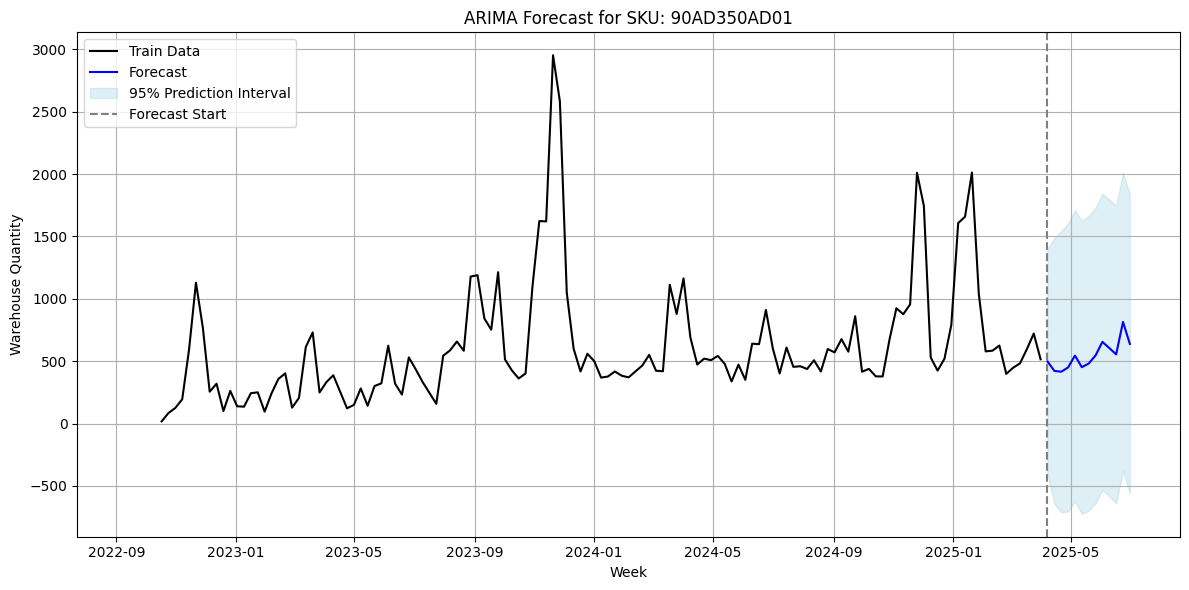


Forecast vs Actuals (Test Period):
             ds  WareHouseQuantity        yhat
1950 2025-04-07                738  497.710047
1959 2025-04-14                432  421.673345
1968 2025-04-21                541  415.057604
1978 2025-04-28                509  449.292685
1987 2025-05-05                506  544.352556
1996 2025-05-12                486  451.667339
2005 2025-05-19                318  480.578059
2016 2025-05-26                414  545.228660
2027 2025-06-02                375  654.289857
2037 2025-06-09                474  604.960575
2047 2025-06-16                475  554.589193
2056 2025-06-23                390  813.990295
2068 2025-06-30                388  637.856367

Accuracy Metrics:
MAE  (Mean Absolute Error):        151.26
MSE  (Mean Squared Error):         35942.96
RMSE (Root Mean Squared Error):    189.59
MAPE (Mean Absolute % Error):      35.34%
R²   (R-squared Score):            -2.61


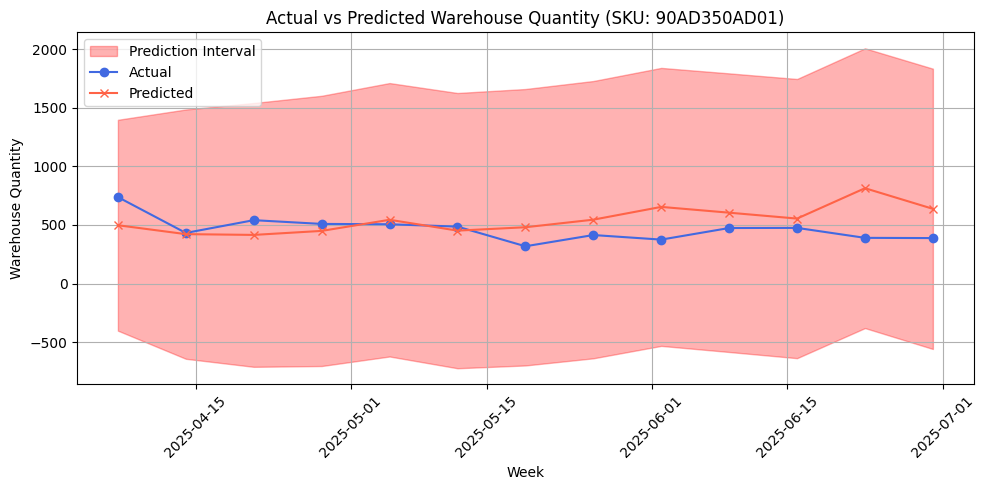


Accuracy within ±10% of predicted values: 23.08%

Final Forecast Results:


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
1950,2025-04-07,2025-04-13,738,498,-240.289953,-32.56%,664,812,Out of Range
1959,2025-04-14,2025-04-20,432,422,-10.326655,-2.39%,389,475,Acceptable
1968,2025-04-21,2025-04-27,541,415,-125.942396,-23.28%,487,595,Out of Range
1978,2025-04-28,2025-05-04,509,449,-59.707315,-11.73%,458,560,Out of Range
1987,2025-05-05,2025-05-11,506,544,38.352556,7.58%,455,557,Acceptable
1996,2025-05-12,2025-05-18,486,452,-34.332661,-7.06%,437,535,Acceptable
2005,2025-05-19,2025-05-25,318,481,162.578059,51.13%,286,350,Out of Range
2016,2025-05-26,2025-06-01,414,545,131.228660,31.7%,373,455,Out of Range
2027,2025-06-02,2025-06-08,375,654,279.289857,74.48%,338,413,Out of Range
2037,2025-06-09,2025-06-15,474,605,130.960575,27.63%,427,521,Out of Range


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare the training series
train_series = train_data.set_index('Week_Start')['WareHouseQuantity'].asfreq('W-MON')

# STEP 2: Fit ARIMA (SARIMAX) Model
# You can tune (p,d,q) as needed
model = SARIMAX(train_series, order=(1,1,1), seasonal_order=(1,1,1,52), enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)

# STEP 3: Forecast
n_test = len(test_data)
forecast_result = results.get_forecast(steps=n_test)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# STEP 4: Plot forecast with prediction interval
plt.figure(figsize=(12, 6))
plt.plot(train_series.index, train_series, label='Train Data', color='black')
plt.plot(test_data['Week_Start'], forecast_mean, label='Forecast', color='blue')
plt.fill_between(test_data['Week_Start'], conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='lightblue', alpha=0.4, label='95% Prediction Interval')
plt.axvline(x=test_start, color='gray', linestyle='--', label='Forecast Start')
plt.title(f"ARIMA Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5: Merge forecast with test data
forecast_df = pd.DataFrame({
    'ds': test_data['Week_Start'],
    'yhat': forecast_mean.values,
    'yhat_lower': conf_int.iloc[:, 0].values,
    'yhat_upper': conf_int.iloc[:, 1].values,
    'WareHouseQuantity': test_data['WareHouseQuantity'].values
})

print("\nForecast vs Actuals (Test Period):")
print(forecast_df[['ds', 'WareHouseQuantity', 'yhat']])

# STEP 6: Evaluation Metrics
y_true = forecast_df['WareHouseQuantity'].values
y_pred = forecast_df['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 7: Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.fill_between(forecast_df['ds'], forecast_df['yhat_lower'], forecast_df['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(forecast_df['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(forecast_df['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 8: Final Results DataFrame
forecast_df['Start_Week'] = forecast_df['ds']
forecast_df['End_Week'] = forecast_df['Start_Week'] + pd.Timedelta(days=6)
forecast_df['Difference_Between_Predicted_And_Actual'] = forecast_df['yhat'] - forecast_df['WareHouseQuantity']
forecast_df['Percent_Difference'] = (
    forecast_df['Difference_Between_Predicted_And_Actual'] / forecast_df['WareHouseQuantity']
) * 100

forecast_df['Rounded_Predicted'] = forecast_df['yhat'].round().astype(int)
forecast_df['Percent_Difference'] = forecast_df['Percent_Difference'].round(2).astype(str) + '%'

final_result = forecast_df[[
    'Start_Week',
    'End_Week',
    'WareHouseQuantity',
    'Rounded_Predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].rename(columns={
    'WareHouseQuantity': 'Actual_WareHouseQuantity',
    'Rounded_Predicted': 'Predicted_WareHouseQuantity'
})

# STEP 9: ±10% Accuracy Evaluation
final_result['Minus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 0.90).round().astype(int)
final_result['Plus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 1.10).round().astype(int)

final_result['Within_10_Percent'] = (
    (final_result['Predicted_WareHouseQuantity'] >= final_result['Minus_10_Percent']) &
    (final_result['Predicted_WareHouseQuantity'] <= final_result['Plus_10_Percent'])
)

final_result['Within_10_Percent'] = final_result['Within_10_Percent'].map({True: 'Acceptable', False: 'Out of Range'})
accuracy_within_10_percent = (final_result['Within_10_Percent'] == 'Acceptable').mean() * 100

print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")
print("\nFinal Forecast Results:")
# print(final_result)

# Optional: Save to CSV
# final_result.to_csv("arima_forecast_results.csv", index=False)
final_result


### ARIMA HyperParameter Tuning

In [16]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Define parameter grid
p = d = q = range(0, 3)  # Non-seasonal parameters
P = D = Q = range(0, 2)  # Seasonal parameters
s = 52  # Weekly data, seasonal cycle of 52 weeks

import itertools
param_grid = list(itertools.product(p, d, q))
seasonal_grid = list(itertools.product(P, D, Q))

# Run grid search
best_score = float("inf")
best_params = None
best_model = None

print("Starting Grid Search for SARIMA Hyperparameters...\n")
for order in param_grid:
    for seasonal_order in seasonal_grid:
        try:
            model = SARIMAX(train_series,
                            order=order,
                            seasonal_order=(seasonal_order[0], seasonal_order[1], seasonal_order[2], s),
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            results = model.fit(disp=False)

            # Choose evaluation metric: AIC or RMSE (here AIC)
            score = results.aic

            if score < best_score:
                best_score = score
                best_params = (order, seasonal_order)
                best_model = results

            print(f"Tested SARIMA{order} x {seasonal_order}52 - AIC: {score:.2f}")

        except Exception as e:
            continue

print("\nBest SARIMA model:")
print(f"Order (p,d,q): {best_params[0]}")
print(f"Seasonal Order (P,D,Q,s): ({best_params[1][0]}, {best_params[1][1]}, {best_params[1][2]}, {s})")
print(f"Best AIC: {best_score:.2f}")


Starting Grid Search for SARIMA Hyperparameters...

Tested SARIMA(0, 0, 0) x (0, 0, 0)52 - AIC: 2097.38
Tested SARIMA(0, 0, 0) x (0, 0, 1)52 - AIC: 1301.13
Tested SARIMA(0, 0, 0) x (0, 1, 0)52 - AIC: 1277.00
Tested SARIMA(0, 0, 0) x (0, 1, 1)52 - AIC: 457.54
Tested SARIMA(0, 0, 0) x (1, 0, 0)52 - AIC: 1293.86
Tested SARIMA(0, 0, 0) x (1, 0, 1)52 - AIC: 1279.50
Tested SARIMA(0, 0, 0) x (1, 1, 0)52 - AIC: 472.56
Tested SARIMA(0, 0, 0) x (1, 1, 1)52 - AIC: 459.54
Tested SARIMA(0, 0, 1) x (0, 0, 0)52 - AIC: 1984.86
Tested SARIMA(0, 0, 1) x (0, 0, 1)52 - AIC: 1224.26
Tested SARIMA(0, 0, 1) x (0, 1, 0)52 - AIC: 1214.26
Tested SARIMA(0, 0, 1) x (0, 1, 1)52 - AIC: 429.46
Tested SARIMA(0, 0, 1) x (1, 0, 0)52 - AIC: 1242.61
Tested SARIMA(0, 0, 1) x (1, 0, 1)52 - AIC: 1211.87
Tested SARIMA(0, 0, 1) x (1, 1, 0)52 - AIC: 459.19
Tested SARIMA(0, 0, 1) x (1, 1, 1)52 - AIC: 431.43
Tested SARIMA(0, 0, 2) x (0, 0, 0)52 - AIC: 1925.05
Tested SARIMA(0, 0, 2) x (0, 0, 1)52 - AIC: 1191.91
Tested SARIMA(0, 0

### SARIMA model Using Hyper parameters:
    - Order (p,d,q): (0, 2, 2)
    - Seasonal Order (P,D,Q,s): (0, 1, 1, 52)
    - Best AIC: 391.57


Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13


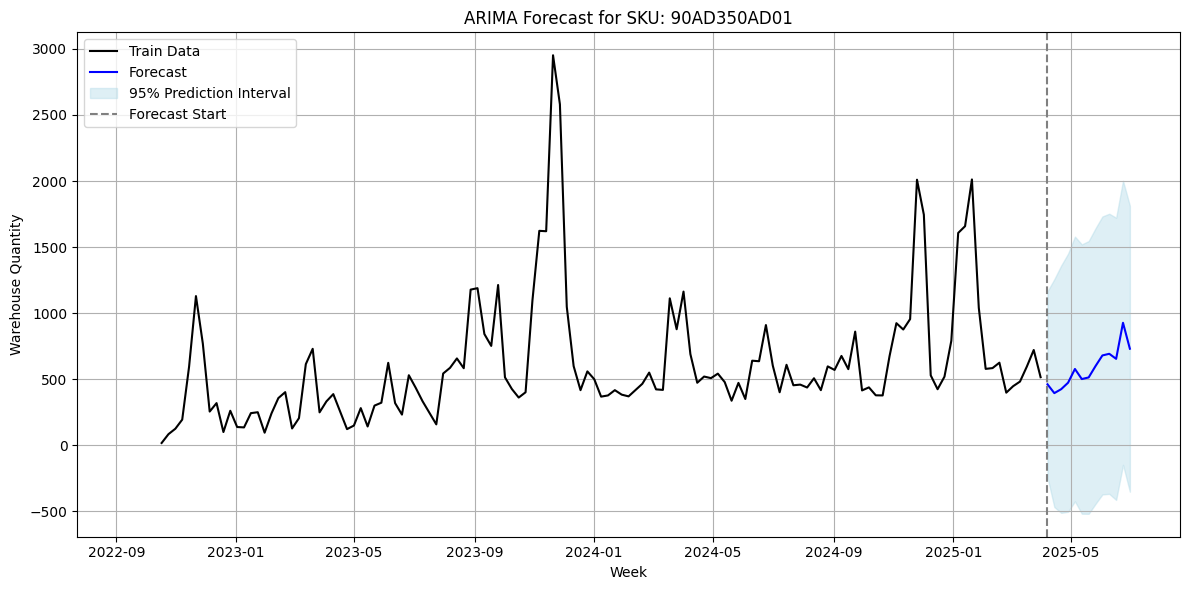


Forecast vs Actuals (Test Period):
             ds  WareHouseQuantity        yhat
1950 2025-04-07                738  461.294668
1959 2025-04-14                432  394.570612
1968 2025-04-21                541  424.538659
1978 2025-04-28                509  473.275249
1987 2025-05-05                506  577.350256
1996 2025-05-12                486  500.968494
2005 2025-05-19                318  513.296052
2016 2025-05-26                414  599.410206
2027 2025-06-02                375  679.695799
2037 2025-06-09                474  692.289652
2047 2025-06-16                475  654.002627
2056 2025-06-23                390  926.934425
2068 2025-06-30                388  730.604669

Accuracy Metrics:
MAE  (Mean Absolute Error):        193.45
MSE  (Mean Squared Error):         57603.62
RMSE (Root Mean Squared Error):    240.01
MAPE (Mean Absolute % Error):      45.31%
R²   (R-squared Score):            -4.78


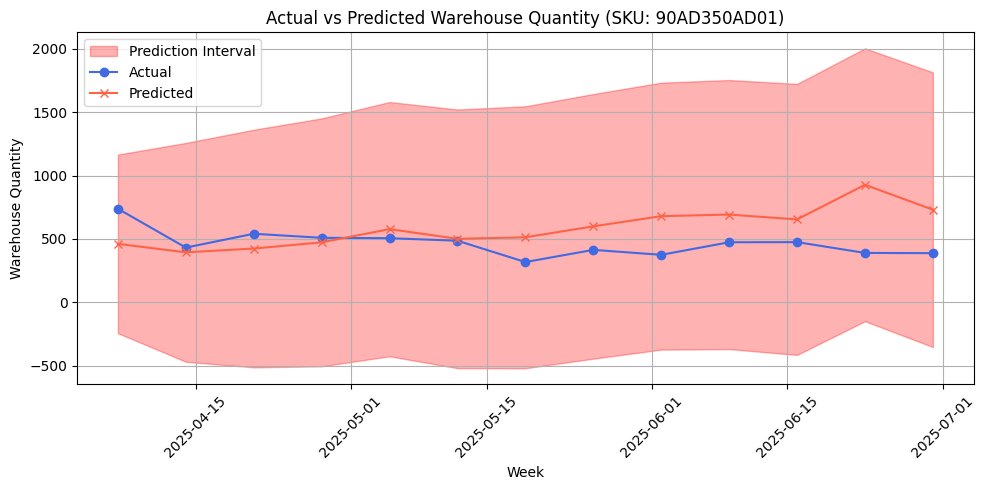


Accuracy within ±10% of predicted values: 23.08%

Final Forecast Results:


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
1950,2025-04-07,2025-04-13,738,461,-276.705332,-37.49%,664,812,Out of Range
1959,2025-04-14,2025-04-20,432,395,-37.429388,-8.66%,389,475,Acceptable
1968,2025-04-21,2025-04-27,541,425,-116.461341,-21.53%,487,595,Out of Range
1978,2025-04-28,2025-05-04,509,473,-35.724751,-7.02%,458,560,Acceptable
1987,2025-05-05,2025-05-11,506,577,71.350256,14.1%,455,557,Out of Range
1996,2025-05-12,2025-05-18,486,501,14.968494,3.08%,437,535,Acceptable
2005,2025-05-19,2025-05-25,318,513,195.296052,61.41%,286,350,Out of Range
2016,2025-05-26,2025-06-01,414,599,185.410206,44.79%,373,455,Out of Range
2027,2025-06-02,2025-06-08,375,680,304.695799,81.25%,338,413,Out of Range
2037,2025-06-09,2025-06-15,474,692,218.289652,46.05%,427,521,Out of Range


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare the training series
train_series = train_data.set_index('Week_Start')['WareHouseQuantity'].asfreq('W-MON')

# STEP 2: Fit ARIMA (SARIMAX) Model
# You can tune (p,d,q) as needed
model = SARIMAX(train_series, order=(1,1,1), seasonal_order=(1,1,1,52), enforce_stationarity=True, enforce_invertibility=True)
results = model.fit(disp=False)

# STEP 3: Forecast
n_test = len(test_data)
forecast_result = results.get_forecast(steps=n_test)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# STEP 4: Plot forecast with prediction interval
plt.figure(figsize=(12, 6))
plt.plot(train_series.index, train_series, label='Train Data', color='black')
plt.plot(test_data['Week_Start'], forecast_mean, label='Forecast', color='blue')
plt.fill_between(test_data['Week_Start'], conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='lightblue', alpha=0.4, label='95% Prediction Interval')
plt.axvline(x=test_start, color='gray', linestyle='--', label='Forecast Start')
plt.title(f"ARIMA Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5: Merge forecast with test data
forecast_df = pd.DataFrame({
    'ds': test_data['Week_Start'],
    'yhat': forecast_mean.values,
    'yhat_lower': conf_int.iloc[:, 0].values,
    'yhat_upper': conf_int.iloc[:, 1].values,
    'WareHouseQuantity': test_data['WareHouseQuantity'].values
})

print("\nForecast vs Actuals (Test Period):")
print(forecast_df[['ds', 'WareHouseQuantity', 'yhat']])

# STEP 6: Evaluation Metrics
y_true = forecast_df['WareHouseQuantity'].values
y_pred = forecast_df['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 7: Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.fill_between(forecast_df['ds'], forecast_df['yhat_lower'], forecast_df['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(forecast_df['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(forecast_df['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 8: Final Results DataFrame
forecast_df['Start_Week'] = forecast_df['ds']
forecast_df['End_Week'] = forecast_df['Start_Week'] + pd.Timedelta(days=6)
forecast_df['Difference_Between_Predicted_And_Actual'] = forecast_df['yhat'] - forecast_df['WareHouseQuantity']
forecast_df['Percent_Difference'] = (
    forecast_df['Difference_Between_Predicted_And_Actual'] / forecast_df['WareHouseQuantity']
) * 100

forecast_df['Rounded_Predicted'] = forecast_df['yhat'].round().astype(int)
forecast_df['Percent_Difference'] = forecast_df['Percent_Difference'].round(2).astype(str) + '%'

final_result = forecast_df[[
    'Start_Week',
    'End_Week',
    'WareHouseQuantity',
    'Rounded_Predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].rename(columns={
    'WareHouseQuantity': 'Actual_WareHouseQuantity',
    'Rounded_Predicted': 'Predicted_WareHouseQuantity'
})

# STEP 9: ±10% Accuracy Evaluation
final_result['Minus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 0.90).round().astype(int)
final_result['Plus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 1.10).round().astype(int)

final_result['Within_10_Percent'] = (
    (final_result['Predicted_WareHouseQuantity'] >= final_result['Minus_10_Percent']) &
    (final_result['Predicted_WareHouseQuantity'] <= final_result['Plus_10_Percent'])
)

final_result['Within_10_Percent'] = final_result['Within_10_Percent'].map({True: 'Acceptable', False: 'Out of Range'})
accuracy_within_10_percent = (final_result['Within_10_Percent'] == 'Acceptable').mean() * 100

print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")
print("\nFinal Forecast Results:")
# print(final_result)

# Optional: Save to CSV
# final_result.to_csv("arima_forecast_results.csv", index=False)
final_result
